# Cycle 1 EDA — CICIDS2017 Cleaning & Split

Explores the raw-data issues clean.py handles (header whitespace, mojibake labels, Inf rate values) and shows class balance before/after cleaning and across the train/val/test split, per Master Architecture Document Pillar 7 Cycle 1.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.preprocessing.clean import RAW_DIR, INTERIM_DIR, load_raw_csvs

Matplotlib is building the font cache; this may take a moment.


## Raw header whitespace issue

CICIDS2017's raw headers famously ship with leading spaces (e.g. `" Flow Duration"`) — a lookup by the clean column name would silently `KeyError` downstream if not stripped.

In [2]:
raw_sample_path = sorted(RAW_DIR.glob("*.csv"))[0]
raw_header = pd.read_csv(raw_sample_path, nrows=0).columns.tolist()
print(raw_sample_path.name)
print(raw_header[:8])

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min']


## Mojibake Web Attack labels

`Thursday-WorkingHours-Morning-WebAttacks.csv` has a corrupted en-dash in its Web Attack labels (already lost upstream — decodes as the UTF-8 replacement character, not a fixable encoding mistake on our end).

In [3]:
web_attacks_path = RAW_DIR / "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
raw_labels = pd.read_csv(web_attacks_path, usecols=[" Label"])[" Label"]
raw_labels.value_counts()

 Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

## Class balance before / after cleaning

Produced by `src/preprocessing/clean.py`, which deduplicates exact-duplicate rows across the full dataset before any split — the mitigation for the documented CICIDS2017 duplicate-flow issue (Engelen et al. 2021, Lanvin et al. 2022).

In [4]:
report_path = INTERIM_DIR / "class_balance_report.json"
report = json.loads(report_path.read_text())

balance_df = pd.DataFrame({"before": report["before"], "after": report["after"]}).fillna(0)
balance_df

,before,after
BENIGN,2273097,2096484
DoS,252661,193748
PortScan,158930,90819
DDoS,128027,128016
Brute Force,13835,9152
Web Attack,2180,2143
Botnet,1966,1953
Infiltration,36,36
Heartbleed,11,11


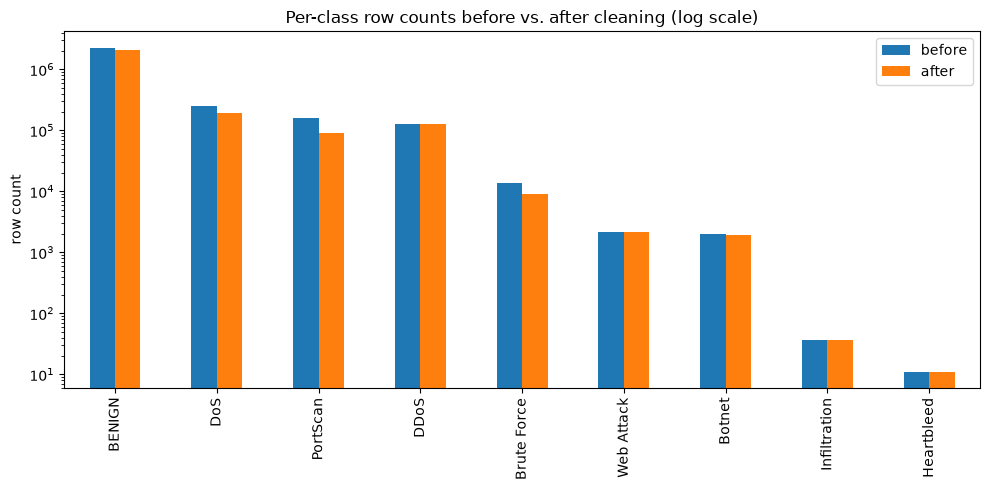

In [5]:
ax = balance_df.plot(kind="bar", figsize=(10, 5), logy=True)
ax.set_title("Per-class row counts before vs. after cleaning (log scale)")
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()

No class drops to zero after cleaning — the rarest classes, Heartbleed (11 rows) and Infiltration (36 rows), survive untouched since they contain no exact duplicates.

## Class balance across the train/val/test split

Split via `src/preprocessing/split.py`: stratified by `(source_day, label_family)` rather than a pure random shuffle or a whole-day holdout — this dataset export has no Flow ID / IP / Timestamp for a true session-level group split, and several attack classes exist in only one source day (e.g. Infiltration only in Thursday-Afternoon), so a whole-day holdout would erase them from train or test entirely.

In [6]:
splits_df = pd.DataFrame(report["splits"]).fillna(0)
splits_df

,train,val,test
BENIGN,1467539,314473,314472
DoS,135624,29062,29062
DDoS,89611,19202,19203
PortScan,63573,13623,13623
Brute Force,6406,1373,1373
Web Attack,1500,321,322
Botnet,1367,293,293
Infiltration,25,5,6
Heartbleed,8,2,1


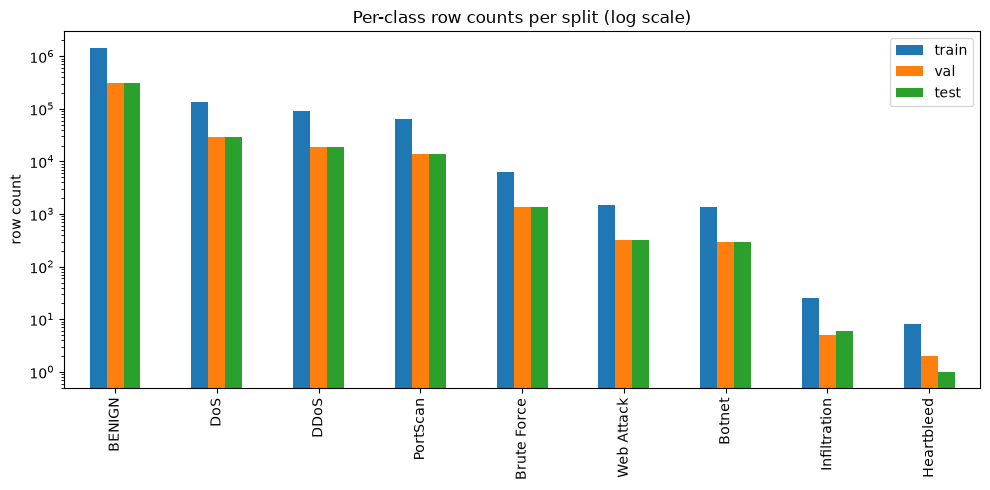

In [7]:
ax = splits_df.plot(kind="bar", figsize=(10, 5), logy=True)
ax.set_title("Per-class row counts per split (log scale)")
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()

## Inf / NaN counts in rate columns

`Flow Bytes/s` and `Flow Packets/s` can be `Infinity` when duration rounds to zero. clean.py replaces these with `NaN` rather than dropping the rows — imputation is deferred to Cycle 2, fit on the training fold only, to avoid leaking val/test statistics into training.

In [8]:
cleaned_df = pd.read_parquet(INTERIM_DIR / "cleaned.parquet", columns=["Flow Bytes/s", "Flow Packets/s"])
cleaned_df.isna().sum()

Flow Bytes/s      1564
Flow Packets/s    1564
dtype: int64